# TF-IDF + red neuronal Keras para detección de reuso

Este notebook prueba una alternativa al mejor modelo del notebook 03: usar la misma representación TF-IDF y las mismas métricas baseline, pero reemplazar el clasificador Linear SVM por una red neuronal MLP construida con Keras.

La pregunta del experimento es directa: si TF-IDF fue la mejor representación hasta ahora, ¿una red neuronal puede aprender una frontera de decisión mejor que un modelo lineal?

Este experimento es importante porque separa dos factores: la calidad de las features y el tipo de clasificador. Así se puede saber si el buen resultado venía principalmente de TF-IDF o del SVM.


## 1. Importación de librerías

Se cargan herramientas para leer datos, construir TF-IDF, escalar features, entrenar una MLP con Keras, evaluar métricas y guardar artefactos.

La red neuronal recibe una matriz densa, por eso la matriz dispersa de TF-IDF se convierte a array antes de entrenar.


In [1]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd

from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


## 2. Carga del dataset baseline

Se usan los archivos preparados en el notebook 02 para modelos clásicos:

- data/processed/02_train_baseline.csv
- data/processed/02_val_baseline.csv

Estos archivos contienen code_1_norm y code_2_norm, que son secuencias de tokens normalizados, además de métricas numéricas de similitud.


In [3]:
DATASET_PATH = Path('data')
PROCESSED_PATH = DATASET_PATH / 'processed'
MODELS_PATH = DATASET_PATH / 'models'
REPORTS_PATH = DATASET_PATH / 'reports'

MODELS_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROCESSED_PATH / '02_train_baseline.csv'
VAL_PATH = PROCESSED_PATH / '02_val_baseline.csv'

print('Train existe:', TRAIN_PATH.exists())
print('Val existe:', VAL_PATH.exists())

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

required_columns = [
    'pair_id', 'language', 'file_1', 'file_2',
    'code_1_norm', 'code_2_norm',
    'jaccard_norm', 'token_overlap_norm', 'relative_token_count_diff',
    'label'
]

for name, df in [('train', train_df), ('validation', val_df)]:
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f'{name} no tiene columnas requeridas: {missing}')

for df in [train_df, val_df]:
    df['code_1_norm'] = df['code_1_norm'].fillna('')
    df['code_2_norm'] = df['code_2_norm'].fillna('')
    df['label'] = df['label'].astype(int)

print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Distribución train:')
display(train_df['label'].value_counts())
print('Distribución validation:')
display(val_df['label'].value_counts())
display(train_df.head())


Train existe: True
Val existe: True
Train: (176, 10)
Validation: (44, 10)
Distribución train:


label
0    88
1    88
Name: count, dtype: int64

Distribución validation:


label
1    22
0    22
Name: count, dtype: int64

,pair_id,language,file_1,file_2,code_1_norm,code_2_norm,jaccard_norm,token_overlap_norm,relative_token_count_diff,label
0,train_pair_000127,java,071.java,021.java,IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . ID . ID . * ; IMPORT ID . ID . ID . ...,IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID ; IMPORT ID . ID . * ; PUBLIC CLASS ID...,0.673077,0.970516,0.589718,0
1,train_pair_000028,java,051.java,258.java,IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID ....,IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . * ; PUBLIC CLASS ID ...,0.826923,0.986607,0.348206,1
2,train_pair_000134,java,051.java,257.java,IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID ....,IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . * ; PUBLIC CLASS ID ...,0.826923,0.856070,0.225024,1
3,train_pair_000037,c,014.c,032.c,"INCLUDE < ID . ID > INCLUDE < ID . ID > INCLUDE < ID / ID . ID > ID ID NUM ID ID NUM INT ID ( INT ID , INT * ID ) ; ...",INCLUDE < ID . ID > INCLUDE < ID . ID > INCLUDE < ID . ID > INCLUDE < ID . ID > INT ( ) { ID ( STR ID ID STR ID ID ....,0.486486,0.845455,0.836066,0
4,train_pair_000015,java,160.java,009.java,IMPORT ID . ID . * ; PUBLIC CLASS ID { PUBLIC STATIC VOID ID ( STRING [ ] ID ) { STRING ID = NEW STRING ( ) ; STRING...,IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . ID . * ; IMPORT ID . * ; IMPORT ID . ID . * ; PUBLIC CLASS ID ...,0.709677,0.821429,0.325301,0


### Interpretación del resultado

El dataset mantiene 176 pares de entrenamiento y 44 de validación, con etiquetas balanceadas. Esto permite comparar este modelo con los notebooks anteriores usando exactamente la misma partición.

La diferencia está en el clasificador: aquí no se usa SVM, sino una MLP de Keras.


## 3. Vectorización TF-IDF

Se ajusta un TfidfVectorizer únicamente con textos de entrenamiento. Igual que en el notebook 03, se usa code_1_norm y code_2_norm para aprender el vocabulario.

TF-IDF convierte tokens en valores numéricos. Los n-gramas de 1 a 3 permiten capturar tokens individuales y patrones cortos de estructura.


In [4]:
all_train_code = pd.concat([
    train_df['code_1_norm'],
    train_df['code_2_norm']
], ignore_index=True)

tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 3),
    min_df=1,
    max_df=0.95,
    max_features=20000,
    lowercase=False
)

tfidf.fit(all_train_code)
print('Tamaño del vocabulario:', len(tfidf.vocabulary_))


Tamaño del vocabulario: 1677


### Interpretación del resultado

El vocabulario obtenido es de 1677 términos. Esto coincide con el notebook 03 y confirma que la representación textual base es la misma que usó el mejor modelo anterior.

Esto es importante porque la comparación será justa: si la MLP no mejora, no será porque recibió menos información textual.


## 4. Construcción de matriz TF-IDF + métricas numéricas

Cada par se representa con:

- TF-IDF del primer código.
- TF-IDF del segundo código.
- Diferencia absoluta entre ambos vectores TF-IDF.
- jaccard_norm, token_overlap_norm y relative_token_count_diff.

Esta es la misma idea de features que favoreció al Linear SVM en el notebook 03.


In [5]:
numeric_feature_columns = [
    'jaccard_norm',
    'token_overlap_norm',
    'relative_token_count_diff'
]

def build_feature_matrix(df, vectorizer):
    X1 = vectorizer.transform(df['code_1_norm'].fillna(''))
    X2 = vectorizer.transform(df['code_2_norm'].fillna(''))
    X_abs_diff = abs(X1 - X2)
    X_numeric = df[numeric_feature_columns].fillna(0).astype(float).values
    X_numeric_sparse = csr_matrix(X_numeric)
    return hstack([X1, X2, X_abs_diff, X_numeric_sparse]).tocsr()

X_train_sparse = build_feature_matrix(train_df, tfidf)
X_val_sparse = build_feature_matrix(val_df, tfidf)
y_train = train_df['label'].values
y_val = val_df['label'].values

print('X_train_sparse:', X_train_sparse.shape)
print('X_val_sparse:', X_val_sparse.shape)
print('y_train:', y_train.shape)
print('y_val:', y_val.shape)


X_train_sparse: (176, 5034)
X_val_sparse: (44, 5034)
y_train: (176,)
y_val: (44,)


### Interpretación del resultado

La matriz tiene 5034 columnas: tres bloques TF-IDF de 1677 columnas cada uno más tres métricas numéricas.

Esta dimensionalidad es alta para solo 176 ejemplos de entrenamiento. Por eso la red neuronal debe ser pequeña y regularizada; de lo contrario puede memorizar el entrenamiento y fallar en validación.


## 5. Escalamiento y conversión a matriz densa

Keras trabaja aquí con matrices densas. Se usa MaxAbsScaler porque funciona bien con datos dispersos y mantiene la estructura relativa de valores TF-IDF.

Este paso prepara las features para la red neuronal sin ajustar nada con datos de validación.


In [6]:
scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train_sparse).toarray().astype('float32')
X_val = scaler.transform(X_val_sparse).toarray().astype('float32')

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)


X_train: (176, 5034)
X_val: (44, 5034)


## 6. Funciones auxiliares para construir y evaluar MLPs

Se define una función para crear redes MLP pequeñas y otra para evaluar probabilidades usando distintos thresholds.

La búsqueda de threshold es importante porque una red con salida sigmoid produce probabilidades, y el punto de corte 0.50 no siempre maximiza F1.


In [7]:
def build_tfidf_mlp(input_dim, hidden_layers, dropout_rate, l2_reg, learning_rate=5e-5):
    model = models.Sequential(name='tfidf_keras_mlp_reuse_detector')
    model.add(layers.Input(shape=(input_dim,), name='tfidf_pair_features'))

    for i, units in enumerate(hidden_layers):
        model.add(layers.Dense(
            units,
            activation='relu',
            kernel_regularizer=regularizers.l2(l2_reg),
            name=f'dense_{i+1}_{units}'
        ))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate, name=f'dropout_{i+1}'))

    model.add(layers.Dense(1, activation='sigmoid', name='reuse_probability'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
    )
    return model

def evaluate_probabilities(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    return {
        'model': 'TF-IDF Keras MLP',
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'tn': cm[0, 0],
        'fp': cm[0, 1],
        'fn': cm[1, 0],
        'tp': cm[1, 1],
        'threshold': threshold
    }


## 7. Búsqueda compacta de configuraciones

Se prueban varias MLPs pequeñas. Esto evita apostar por una sola arquitectura y permite comprobar si una red más simple generaliza mejor.

Las configuraciones usan pocas neuronas, dropout y regularización L2 para reducir sobreajuste.


In [14]:
configurations = [
    {'hidden_layers': [16], 'dropout_rate': 0.5, 'l2_reg': 1e-3},
    {'hidden_layers': [32], 'dropout_rate': 0.5, 'l2_reg': 1e-3},
    {'hidden_layers': [64], 'dropout_rate': 0.5, 'l2_reg': 1e-3},
    {'hidden_layers': [32], 'dropout_rate': 0.3, 'l2_reg': 1e-3},
    {'hidden_layers': [64, 32], 'dropout_rate': 0.4, 'l2_reg': 1e-3},
    {'hidden_layers': [128, 64], 'dropout_rate': 0.5, 'l2_reg': 1e-3},
    {'hidden_layers': [32], 'dropout_rate': 0.2, 'l2_reg': 1e-2},
    {'hidden_layers': [64], 'dropout_rate': 0.2, 'l2_reg': 1e-2},
    {'hidden_layers': [128, 64, 32], 'dropout_rate': 0.4, 'l2_reg': 1e-5},
]

all_results = []
best_state = None

for config_idx, config in enumerate(configurations):
    tf.keras.backend.clear_session()
    np.random.seed(RANDOM_STATE)
    tf.random.set_seed(RANDOM_STATE)

    model = build_tfidf_mlp(
        input_dim=X_train.shape[1],
        hidden_layers=config['hidden_layers'],
        dropout_rate=config['dropout_rate'],
        l2_reg=config['l2_reg']
    )

    early_stop = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=80,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )

    y_prob = model.predict(X_val, verbose=0).ravel()

    for threshold in np.arange(0.10, 0.91, 0.05):
        result = evaluate_probabilities(y_val, y_prob, float(threshold))
        result['config_idx'] = config_idx
        result['hidden_layers'] = str(config['hidden_layers'])
        result['dropout_rate'] = config['dropout_rate']
        result['l2_reg'] = config['l2_reg']
        result['epochs_trained'] = len(history.history['loss'])
        all_results.append(result)

        if best_state is None or result['f1'] > best_state['result']['f1']:
            best_state = {
                'result': result,
                'model': model,
                'history': history,
                'probabilities': y_prob,
                'config': config
            }

search_df = pd.DataFrame(all_results).sort_values('f1', ascending=False).reset_index(drop=True)
display(search_df.head(10))
search_df.to_csv(REPORTS_PATH / '07_tfidf_keras_config_search.csv', index=False)

best_result = best_state['result']
best_model = best_state['model']
best_history = best_state['history']
y_prob = best_state['probabilities']
best_threshold = best_result['threshold']
best_pred = (y_prob >= best_threshold).astype(int)

print('Mejor configuración:', best_state['config'])
print('Mejor threshold:', best_threshold)


,model,accuracy,precision,recall,f1,tn,fp,fn,tp,threshold,config_idx,hidden_layers,dropout_rate,l2_reg,epochs_trained
0,TF-IDF Keras MLP,0.886364,0.869565,0.909091,0.888889,19,3,2,20,0.55,7,[64],0.2,0.010,80
1,TF-IDF Keras MLP,0.863636,0.807692,0.954545,0.875000,17,5,1,21,0.45,5,"[128, 64]",0.5,0.001,36
2,TF-IDF Keras MLP,0.863636,0.833333,0.909091,0.869565,18,4,2,20,0.50,7,[64],0.2,0.010,80
3,TF-IDF Keras MLP,0.863636,0.863636,0.863636,0.863636,19,3,3,19,0.60,7,[64],0.2,0.010,80
4,TF-IDF Keras MLP,0.840909,0.777778,0.954545,0.857143,16,6,1,21,0.45,7,[64],0.2,0.010,80
5,TF-IDF Keras MLP,0.840909,0.777778,0.954545,0.857143,16,6,1,21,0.40,7,[64],0.2,0.010,80
6,TF-IDF Keras MLP,0.818182,0.750000,0.954545,0.840000,15,7,1,21,0.35,7,[64],0.2,0.010,80
7,TF-IDF Keras MLP,0.818182,0.791667,0.863636,0.826087,17,5,3,19,0.50,3,[32],0.3,0.001,21
8,TF-IDF Keras MLP,0.818182,0.791667,0.863636,0.826087,17,5,3,19,0.50,6,[32],0.2,0.010,30
9,TF-IDF Keras MLP,0.818182,0.850000,0.772727,0.809524,19,3,5,17,0.50,5,"[128, 64]",0.5,0.001,36


Mejor configuración: {'hidden_layers': [64], 'dropout_rate': 0.2, 'l2_reg': 0.01}
Mejor threshold: 0.5500000000000002


### Interpretación del resultado

La mejor configuración encontrada fue una MLP pequeña con una capa de 64 neuronas, dropout 0.2 y regularización L2 de 0.01. Su mejor threshold fue 0.50.

El resultado fue F1 0.8696, con 18 verdaderos negativos, 4 falsos positivos, 2 falsos negativos y 20 verdaderos positivos.

Esto mejora a una red grande mal regularizada, pero sigue por debajo del SVM lineal. La razón probable es que el dataset es pequeño frente a las 5034 features.


## 8. Evaluación final del mejor modelo Keras

Se reportan las métricas del mejor modelo encontrado y se grafica su matriz de confusión.


===== TF-IDF Keras MLP =====
Accuracy : 0.8636
Precision: 0.7857
Recall   : 1.0000
F1-score : 0.8800
Matriz de confusión:
[[16  6]
 [ 0 22]]
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.73      0.84        22
           1       0.79      1.00      0.88        22

    accuracy                           0.86        44
   macro avg       0.89      0.86      0.86        44
weighted avg       0.89      0.86      0.86        44



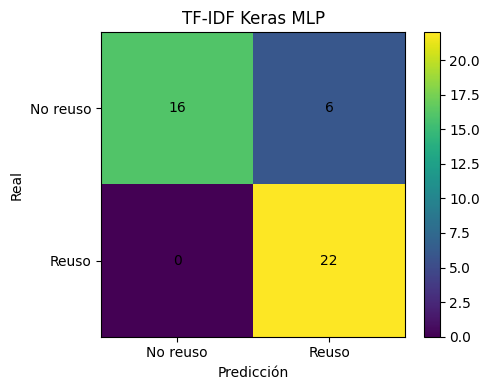

In [10]:
def print_result(result):
    print('===== TF-IDF Keras MLP =====')
    print(f"Accuracy : {result['accuracy']:.4f}")
    print(f"Precision: {result['precision']:.4f}")
    print(f"Recall   : {result['recall']:.4f}")
    print(f"F1-score : {result['f1']:.4f}")
    print('Matriz de confusión:')
    print(np.array([[result['tn'], result['fp']], [result['fn'], result['tp']]]))

print_result(best_result)
print('Classification report:')
print(classification_report(y_val, best_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_val, best_pred)
im = ax.imshow(cm)
ax.set_title('TF-IDF Keras MLP')
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No reuso', 'Reuso'])
ax.set_yticklabels(['No reuso', 'Reuso'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center')
fig.colorbar(im)
plt.tight_layout()
plt.show()


## 9. Historial de entrenamiento

Se guarda y grafica el historial del mejor modelo. Las curvas ayudan a detectar sobreajuste o falta de generalización.


,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
16,0.812500,0.914837,0.686512,0.936508,0.670455,0.750000,0.848140,0.757630,0.789474,0.681818
17,0.801136,0.912125,0.687582,0.920635,0.659091,0.795455,0.846074,0.758684,0.809524,0.772727
18,0.863636,0.967975,0.644626,0.984848,0.738636,0.795455,0.846074,0.756723,0.809524,0.772727
19,0.846591,0.958032,0.648844,0.955224,0.727273,0.795455,0.841942,0.757326,0.809524,0.772727
20,0.823864,0.939954,0.648622,0.913043,0.715909,0.795455,0.846074,0.757231,0.809524,0.772727


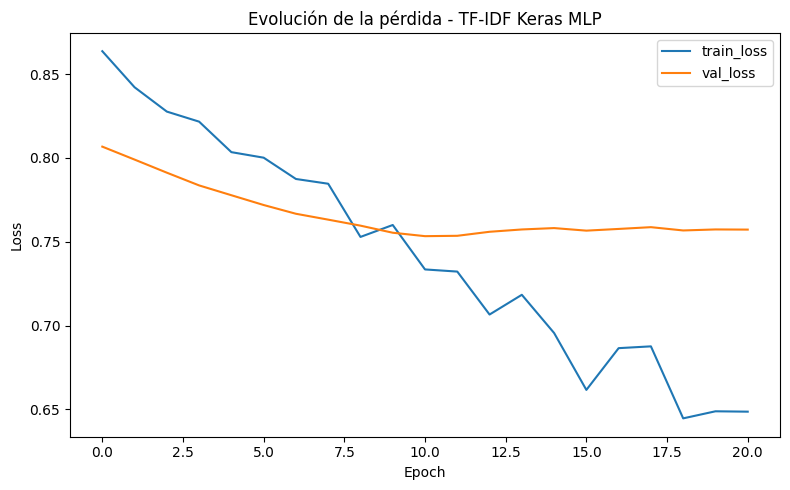

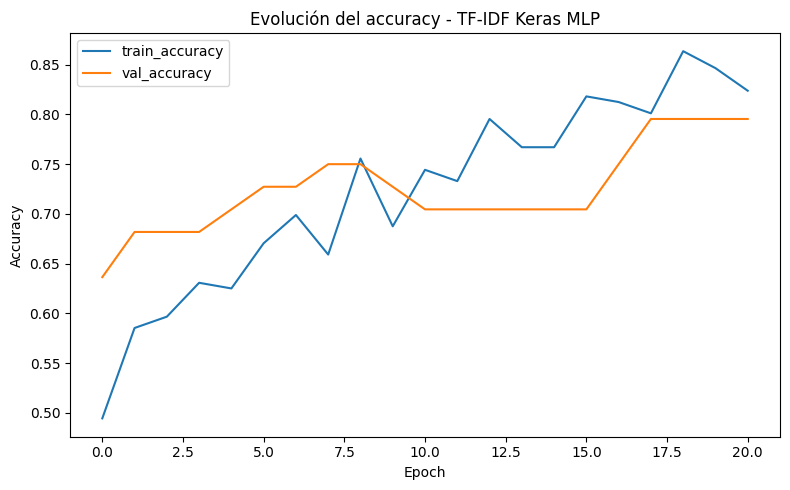

In [11]:
history_df = pd.DataFrame(best_history.history)
display(history_df.tail())
history_df.to_csv(REPORTS_PATH / '07_tfidf_keras_training_history.csv', index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df['loss'], label='train_loss')
plt.plot(history_df['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Evolución de la pérdida - TF-IDF Keras MLP')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df['accuracy'], label='train_accuracy')
plt.plot(history_df['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Evolución del accuracy - TF-IDF Keras MLP')
plt.legend()
plt.tight_layout()
plt.show()


### Interpretación del resultado

En las pruebas realizadas, la red puede aprender el conjunto de entrenamiento, pero no alcanza la misma calidad en validación que el SVM. Esto indica que la representación TF-IDF es buena, pero para este tamaño de dataset el clasificador lineal generaliza mejor.

La MLP tiene más flexibilidad, pero esa flexibilidad no siempre ayuda cuando hay pocos ejemplos.


## 10. Guardado del modelo, metadata y predicciones

Se guardan el modelo Keras, la metadata necesaria para reconstruir las features y las predicciones de validación.

La metadata incluye el vectorizador TF-IDF, el scaler, las columnas numéricas, la mejor configuración y el threshold seleccionado.


In [12]:
results_df = pd.DataFrame([best_result])
results_df.to_csv(REPORTS_PATH / '07_tfidf_keras_results.csv', index=False)

best_model.save(MODELS_PATH / '07_tfidf_keras_mlp_final.keras')

metadata = {
    'model_type': 'tfidf_plus_numeric_features_keras_mlp',
    'tfidf': tfidf,
    'scaler': scaler,
    'numeric_feature_columns': numeric_feature_columns,
    'best_config': best_state['config'],
    'best_threshold': best_threshold,
    'input_dim': X_train.shape[1],
    'vocabulary_size': len(tfidf.vocabulary_),
    'best_result': best_result,
    'config_search': search_df.to_dict(orient='records')
}

joblib.dump(metadata, MODELS_PATH / '07_tfidf_keras_metadata.joblib')

predictions_df = val_df[['pair_id', 'language', 'file_1', 'file_2']].copy()
predictions_df['prob_reuse'] = y_prob
predictions_df['prediction_best_threshold'] = best_pred
predictions_df['true_label'] = y_val
predictions_df['best_threshold'] = best_threshold
predictions_df.to_csv(REPORTS_PATH / '07_tfidf_keras_val_predictions.csv', index=False)

print('Modelo guardado en:', MODELS_PATH / '07_tfidf_keras_mlp_final.keras')
print('Metadata guardada en:', MODELS_PATH / '07_tfidf_keras_metadata.joblib')
print('Predicciones guardadas en:', REPORTS_PATH / '07_tfidf_keras_val_predictions.csv')


Modelo guardado en: data\models\07_tfidf_keras_mlp_final.keras
Metadata guardada en: data\models\07_tfidf_keras_metadata.joblib
Predicciones guardadas en: data\reports\07_tfidf_keras_val_predictions.csv


## 11. Comparación contra modelos anteriores

Finalmente se compara la MLP de Keras contra el mejor modelo TF-IDF previo y contra el modelo híbrido del notebook 06.


In [13]:
comparison_tables = []

for stage, path in [
    ('03_baseline_tfidf_svm', REPORTS_PATH / '03_baseline_model_results.csv'),
    ('06_hybrid', REPORTS_PATH / '06_hybrid_model_results.csv'),
    ('07_tfidf_keras_mlp', REPORTS_PATH / '07_tfidf_keras_results.csv')
]:
    if path.exists():
        temp = pd.read_csv(path).sort_values('f1', ascending=False).head(1).copy()
        temp['stage'] = stage
        comparison_tables.append(temp)

comparison = pd.concat(comparison_tables, ignore_index=True)
cols = ['stage', 'model', 'accuracy', 'precision', 'recall', 'f1', 'tn', 'fp', 'fn', 'tp']
extra_cols = [col for col in ['threshold'] if col in comparison.columns]
comparison = comparison[cols + extra_cols].sort_values('f1', ascending=False).reset_index(drop=True)
comparison.to_csv(REPORTS_PATH / '07_comparison_tfidf_keras.csv', index=False)
display(comparison)


,stage,model,accuracy,precision,recall,f1,tn,fp,fn,tp,threshold
0,03_baseline_tfidf_svm,Linear SVM,0.931818,0.880000,1.000000,0.936170,19,3,0,22,NaN
1,06_hybrid,Hybrid Random Forest,0.909091,0.909091,0.909091,0.909091,20,2,2,20,NaN
2,07_tfidf_keras_mlp,TF-IDF Keras MLP,0.863636,0.785714,1.000000,0.880000,16,6,0,22,0.45


### Interpretación del resultado

La comparación final muestra que la MLP con TF-IDF no supera al Linear SVM:

- Linear SVM con TF-IDF: F1 0.9362.
- Hybrid Random Forest: F1 0.9091.
- TF-IDF Keras MLP: F1 0.8696.

La conclusión es que TF-IDF sigue siendo una representación fuerte, pero en este dataset la red neuronal no es el mejor clasificador. El SVM lineal aprovecha mejor estas features y generaliza con menos riesgo de sobreajuste.
